In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, f1_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

In [3]:
kz = pd.read_csv("kase.csv")
us = pd.read_csv("us.csv")

print(f"\nKZ акции: {kz.shape[0]} строк, {kz.shape[1]} колонок")
print(f"US акции: {us.shape[0]} строк, {us.shape[1]} колонок")



KZ акции: 27252 строк, 35 колонок
US акции: 84277 строк, 50 колонок



--- KZ данные ---
Типы данных:
float64    33
object      2
Name: count, dtype: int64
Пропуски: 0 ячеек

--- US данные ---
Типы данных:
float64    47
object      2
int64       1
Name: count, dtype: int64
Пропуски: 1026630 ячеек

--- Распределение целевых классов ---


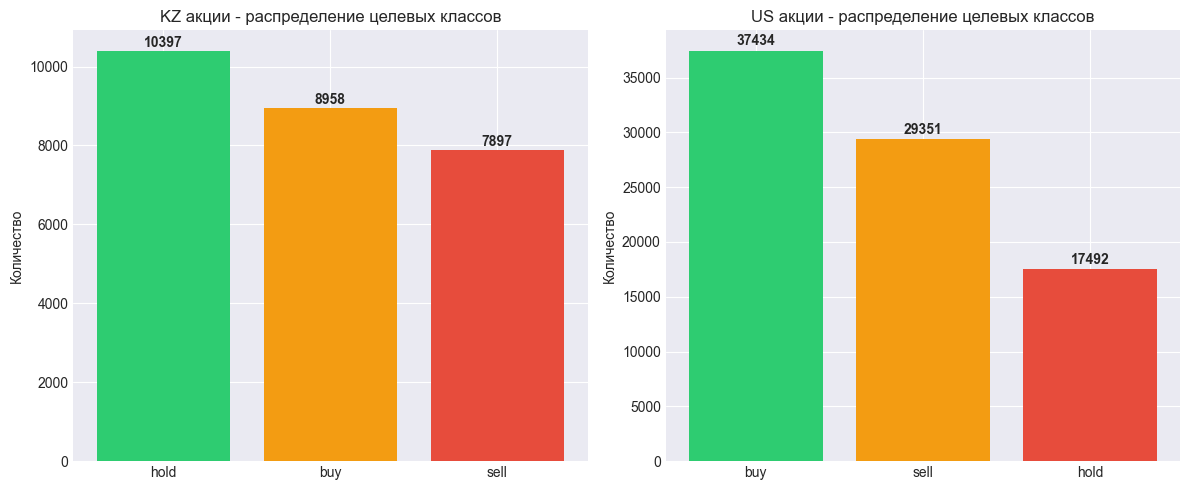


KZ дисбаланс: buy=8958, hold=10397, sell=7897
US дисбаланс: buy=37434, hold=17492, sell=29351

--- Проверка на утечку данных ---
Целевая переменная (ret_fwd_20) НЕ используется как признак

--- Временной анализ ---
KZ период: 2019-03-15 00:00:00 до 2026-03-20 00:00:00
US период: 2021-06-30 00:00:00 до 2026-03-23 00:00:00


In [4]:
# Информация о данных
print("\n--- KZ данные ---")
print(f"Типы данных:\n{kz.dtypes.value_counts()}")
print(f"Пропуски: {kz.isnull().sum().sum()} ячеек")

print("\n--- US данные ---")
print(f"Типы данных:\n{us.dtypes.value_counts()}")
print(f"Пропуски: {us.isnull().sum().sum()} ячеек")

# Создание целевой переменной
def create_target(df):
    def label(x):
        if x > 0.02:
            return "buy"
        elif x < -0.02:
            return "sell"
        else:
            return "hold"
    
    df['target'] = df['ret_fwd_20'].apply(label)
    return df

kz = create_target(kz)
us = create_target(us)

print("\n--- Распределение целевых классов ---")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

kz_counts = kz['target'].value_counts()
us_counts = us['target'].value_counts()

axes[0].bar(kz_counts.index, kz_counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('KZ акции - распределение целевых классов', fontsize=12)
axes[0].set_ylabel('Количество')
for i, v in enumerate(kz_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].bar(us_counts.index, us_counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_title('US акции - распределение целевых классов', fontsize=12)
axes[1].set_ylabel('Количество')
for i, v in enumerate(us_counts.values):
    axes[1].text(i, v + 500, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nKZ дисбаланс: buy={kz_counts['buy']}, hold={kz_counts['hold']}, sell={kz_counts['sell']}")
print(f"US дисбаланс: buy={us_counts['buy']}, hold={us_counts['hold']}, sell={us_counts['sell']}")

# Проверка на утечку данных (look-ahead bias)
print("\n--- Проверка на утечку данных ---")
if 'ret_fwd_20' in kz.columns and 'ret_fwd_20' not in kz.columns.tolist():
    print("ВНИМАНИЕ: ret_fwd_20 может быть в данных!")
else:
    print("Целевая переменная (ret_fwd_20) НЕ используется как признак")

# Временной анализ
print("\n--- Временной анализ ---")
if 'date' in kz.columns:
    kz['date'] = pd.to_datetime(kz['date'])
    us['date'] = pd.to_datetime(us['date'])
    print(f"KZ период: {kz['date'].min()} до {kz['date'].max()}")
    print(f"US период: {us['date'].min()} до {us['date'].max()}")
else:
    print("Колонка 'date' не найдена, временной анализ пропущен")

In [5]:
# Технические признаки
tech_features = ['open', 'high', 'low', 'close', 'adj_close', 'volume',
                 'ret_1d', 'ret_5d', 'ret_10d', 'ret_20d', 'sma_20', 'sma_50',
                 'ema_12', 'ema_26', 'price_to_sma50', 'rsi_14', 'macd', 
                 'macd_signal', 'macd_hist', 'stoch_k', 'bb_upper', 'bb_lower',
                 'bb_width', 'atr_14', 'volume_ratio_20', 'volume_roc', 'obv',
                 'overnight_gap', 'intraday_range', 'sigma_20d']

# Фундаментальные признаки (только US)
fund_features = ['eps', 'revenue', 'revenue_growth_yoy', 'gross_margin', 
                 'operating_margin', 'net_margin', 'roe', 'debt_to_equity',
                 'current_ratio', 'fcf', 'operating_cf', 'pe_ttm', 'pb', 
                 'ps_ttm', 'days_since_report']

# Создаем датасеты
kz_tech = kz[tech_features + ['target']].copy()
us_tech = us[tech_features + ['target']].copy()
us_fund = us[fund_features + ['target']].copy()

print(f"KZ (технические): {kz_tech.shape[0]} строк, {kz_tech.shape[1]} колонок")
print(f"US (технические): {us_tech.shape[0]} строк, {us_tech.shape[1]} колонок")
print(f"US (фундаментальные): {us_fund.shape[0]} строк, {us_fund.shape[1]} колонок")

KZ (технические): 27252 строк, 31 колонок
US (технические): 84277 строк, 31 колонок
US (фундаментальные): 84277 строк, 16 колонок


In [6]:
def prepare_data(df, features, scaler=None):
    df_clean = df.dropna(subset=['target']).copy()
    
    # Кодируем target
    le = LabelEncoder()
    df_clean['target_encoded'] = le.fit_transform(df_clean['target'])
    
    X = df_clean[features].copy()
    y = df_clean['target_encoded']
    
    # Заполняем NaN
    imputer = SimpleImputer(strategy='median')
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    
    # Масштабирование
    if scaler is None:
        scaler = StandardScaler()
        X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns, index=X.index)
    else:
        X_scaled = pd.DataFrame(scaler.transform(X_imputed), columns=X.columns, index=X.index)
    
    return X_scaled, y, le, scaler

# Подготавливаем все три набора
Xk, yk, le_kz, scaler_kz = prepare_data(kz_tech, tech_features)
Xu_tech, yu_tech, le_us_tech, scaler_us_tech = prepare_data(us_tech, tech_features)
Xu_fund, yu_fund, le_us_fund, scaler_us_fund = prepare_data(us_fund, fund_features)

print(f"\nKZ: {Xk.shape[0]} строк, {Xk.shape[1]} признаков")
print(f"US (тех): {Xu_tech.shape[0]} строк, {Xu_tech.shape[1]} признаков")
print(f"US (фунд): {Xu_fund.shape[0]} строк, {Xu_fund.shape[1]} признаков")


KZ: 27252 строк, 30 признаков
US (тех): 84277 строк, 30 признаков
US (фунд): 84277 строк, 15 признаков


In [7]:
# Random split
Xk_train, Xk_test, yk_train, yk_test = train_test_split(
    Xk, yk, test_size=0.2, random_state=42, stratify=yk
)

Xu_tech_train, Xu_tech_test, yu_tech_train, yu_tech_test = train_test_split(
    Xu_tech, yu_tech, test_size=0.2, random_state=42, stratify=yu_tech
)

Xu_fund_train, Xu_fund_test, yu_fund_train, yu_fund_test = train_test_split(
    Xu_fund, yu_fund, test_size=0.2, random_state=42, stratify=yu_fund
)

print(f"\nKZ: train={Xk_train.shape[0]}, test={Xk_test.shape[0]}")
print(f"US тех: train={Xu_tech_train.shape[0]}, test={Xu_tech_test.shape[0]}")
print(f"US фунд: train={Xu_fund_train.shape[0]}, test={Xu_fund_test.shape[0]}")


KZ: train=21801, test=5451
US тех: train=67421, test=16856
US фунд: train=67421, test=16856


In [9]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    
    print(f"{name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['buy', 'hold', 'sell']))
    
    # ROC-AUC для многоклассовой
    if y_pred_proba is not None:
        from sklearn.preprocessing import label_binarize
        y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
        auc = roc_auc_score(y_test_bin, y_pred_proba, average='weighted', multi_class='ovr')
        print(f"Weighted ROC-AUC: {auc:.4f}")
    
    return model, acc

# Модель 1: KZ акции
model_kz = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_kz, acc_kz = train_and_evaluate(
    model_kz, Xk_train, yk_train, Xk_test, yk_test,
    "МОДЕЛЬ 1: KZ акции (технические признаки)"
)

# Модель 2: US технические
model_us_tech = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_us_tech, acc_us_tech = train_and_evaluate(
    model_us_tech, Xu_tech_train, yu_tech_train, Xu_tech_test, yu_tech_test,
    "МОДЕЛЬ 2: US акции (технические признаки)"
)

# Модель 3: US фундаментальные
model_us_fund = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model_us_fund, acc_us_fund = train_and_evaluate(
    model_us_fund, Xu_fund_train, yu_fund_train, Xu_fund_test, yu_fund_test,
    "МОДЕЛЬ 3: US акции (фундаментальные признаки)"
)


МОДЕЛЬ 1: KZ акции (технические признаки)
Accuracy: 0.6769

Classification Report:
              precision    recall  f1-score   support

         buy       0.68      0.72      0.70      1792
        hold       0.67      0.69      0.68      2080
        sell       0.68      0.61      0.64      1579

    accuracy                           0.68      5451
   macro avg       0.68      0.67      0.67      5451
weighted avg       0.68      0.68      0.68      5451

Weighted ROC-AUC: 0.8479
МОДЕЛЬ 2: US акции (технические признаки)
Accuracy: 0.5496

Classification Report:
              precision    recall  f1-score   support

         buy       0.52      0.93      0.67      7487
        hold       0.72      0.01      0.03      3499
        sell       0.65      0.39      0.48      5870

    accuracy                           0.55     16856
   macro avg       0.63      0.44      0.39     16856
weighted avg       0.61      0.55      0.47     16856

Weighted ROC-AUC: 0.7381
МОДЕЛЬ 3: US акции (фу

In [10]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(Xk_train, yk_train)
dummy_pred = dummy.predict(Xk_test)
dummy_acc = accuracy_score(yk_test, dummy_pred)

print(f"Accuracy: {dummy_acc:.4f}")
print(f"Улучшение RandomForest над бейзлайном: {acc_kz - dummy_acc:.4f}")

Accuracy: 0.3816
Улучшение RandomForest над бейзлайном: 0.2954



              Модель  Accuracy  Признаков F1-score (macro)
    KZ (технические)  0.676940         30           0.6744
    US (технические)  0.549597         30           0.3936
US (фундаментальные)  0.496915         15           0.3155
            Бейзлайн  0.381581          0           0.1841


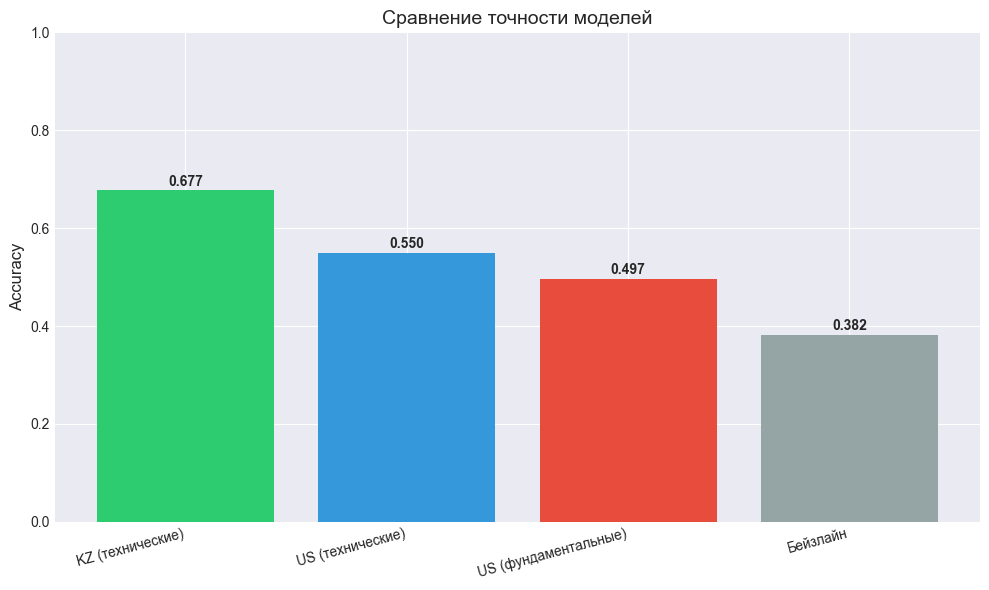

In [11]:
comparison_data = {
    'Модель': ['KZ (технические)', 'US (технические)', 'US (фундаментальные)', 'Бейзлайн'],
    'Accuracy': [acc_kz, acc_us_tech, acc_us_fund, dummy_acc],
    'Признаков': [len(tech_features), len(tech_features), len(fund_features), 0],
    'F1-score (macro)': [
        f1_score(yk_test, model_kz.predict(Xk_test), average='macro'),
        f1_score(yu_tech_test, model_us_tech.predict(Xu_tech_test), average='macro'),
        f1_score(yu_fund_test, model_us_fund.predict(Xu_fund_test), average='macro'),
        f1_score(yk_test, dummy_pred, average='macro')
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['F1-score (macro)'] = comparison_df['F1-score (macro)'].apply(lambda x: f"{x:.4f}")
print("\n" + comparison_df.to_string(index=False))

# Визуализация сравнения
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#95a5a6']
bars = ax.bar(comparison_df['Модель'], [acc_kz, acc_us_tech, acc_us_fund, dummy_acc], color=colors)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Сравнение точности моделей', fontsize=14)
ax.set_ylim(0, 1)
for bar, acc in zip(bars, [acc_kz, acc_us_tech, acc_us_fund, dummy_acc]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{acc:.3f}', ha='center', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


In [12]:
def cross_validate_model(model, X, y, name):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    
    print(f"\n{name}:")
    print(f"   Средняя accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"   Все значения: {[f'{s:.4f}' for s in scores]}")
    return scores

cv_kz = cross_validate_model(RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
                             Xk, yk, "KZ акции")
cv_us = cross_validate_model(RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
                             Xu_tech, yu_tech, "US акции (технические)")


KZ акции:
   Средняя accuracy: 0.6792 (+/- 0.0083)
   Все значения: ['0.6870', '0.6694', '0.6848', '0.6688', '0.6861']

US акции (технические):
   Средняя accuracy: 0.5493 (+/- 0.0031)
   Все значения: ['0.5451', '0.5467', '0.5501', '0.5538', '0.5506']



Топ-10 самых важных признаков (корреляция с таргетом):
   rsi_14: 0.0715
   obv: 0.0613
   volume_ratio_20: 0.0202
   volume: 0.0201
   stoch_k: 0.0198
   price_to_sma50: -0.0011
   ret_20d: -0.0021
   volume_roc: -0.0033
   macd_signal: -0.0109


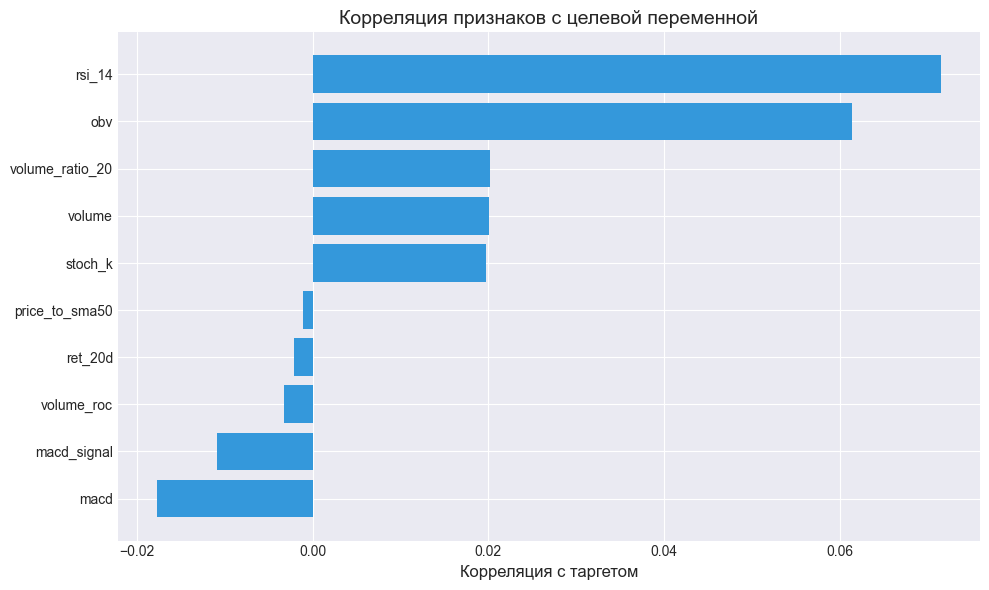

In [13]:
# Кодируем target для корреляции
kz_corr = kz[tech_features].copy()
kz_corr['target_num'] = kz['target'].map({'buy': 2, 'hold': 1, 'sell': 0})

correlations = kz_corr.corr()['target_num'].sort_values(ascending=False)

print("\nТоп-10 самых важных признаков (корреляция с таргетом):")
for feat, corr in correlations.head(10).items():
    if feat != 'target_num':
        print(f"   {feat}: {corr:.4f}")

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
top_features = correlations.head(11).drop('target_num', errors='ignore')
bars = ax.barh(range(len(top_features)), top_features.values, color='#3498db')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index)
ax.set_xlabel('Корреляция с таргетом', fontsize=12)
ax.set_title('Корреляция признаков с целевой переменной', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Топ-10 важных признаков для KZ акции:
   bb_width: 0.0838
   sigma_20d: 0.0766
   obv: 0.0680
   atr_14: 0.0649
   price_to_sma50: 0.0434
   sma_50: 0.0424
   ema_26: 0.0356
   intraday_range: 0.0354
   bb_lower: 0.0352
   bb_upper: 0.0344


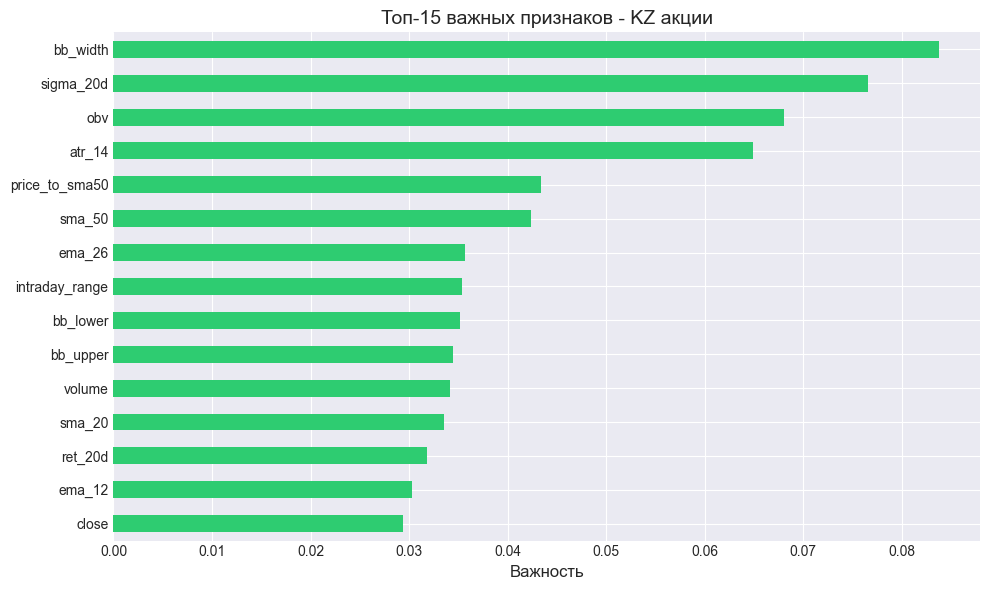


Топ-10 важных признаков для US акции (технические):
   atr_14: 0.0754
   obv: 0.0658
   sigma_20d: 0.0583
   sma_50: 0.0484
   macd_signal: 0.0440
   overnight_gap: 0.0432
   bb_lower: 0.0399
   ema_26: 0.0392
   bb_upper: 0.0384
   ema_12: 0.0383


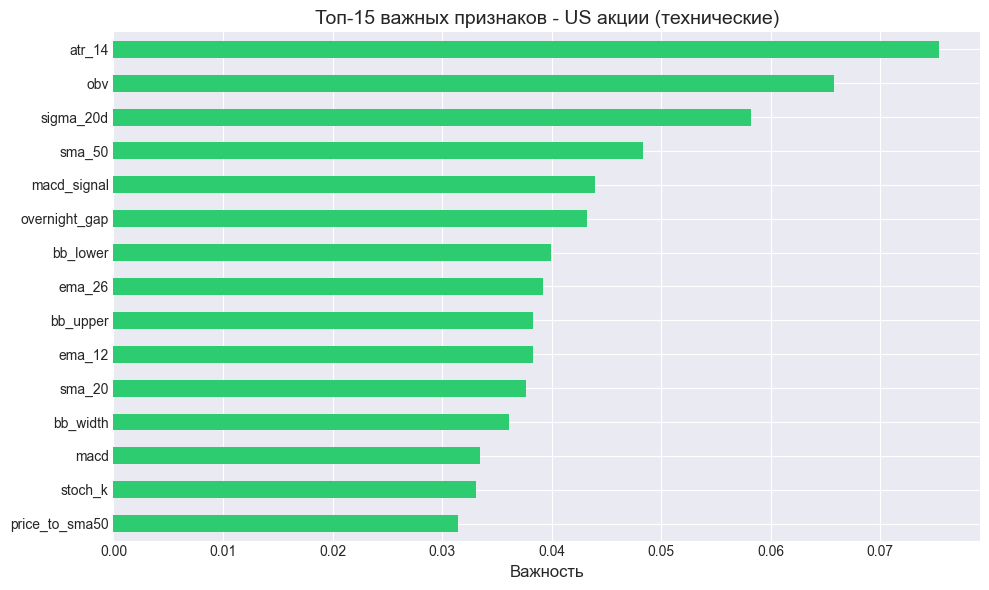

In [14]:
def plot_feature_importance(model, feature_names, title):
    importance = pd.Series(model.feature_importances_, index=feature_names)
    importance = importance.sort_values(ascending=False).head(15)
    
    print(f"\nТоп-10 важных признаков для {title}:")
    for feat, imp in importance.head(10).items():
        print(f"   {feat}: {imp:.4f}")
    
    plt.figure(figsize=(10, 6))
    importance.plot(kind='barh', color='#2ecc71')
    plt.xlabel('Важность', fontsize=12)
    plt.title(f'Топ-15 важных признаков - {title}', fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_feature_importance(model_kz, Xk.columns, "KZ акции")
plot_feature_importance(model_us_tech, Xu_tech.columns, "US акции (технические)")

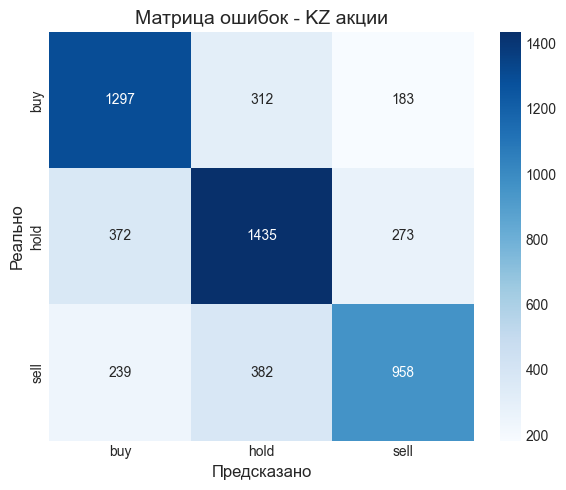


Анализ ошибок для KZ акции:
   Правильно предсказано: 3690/5451 (67.7%)
   Ошибок всего: 1761 (32.3%)


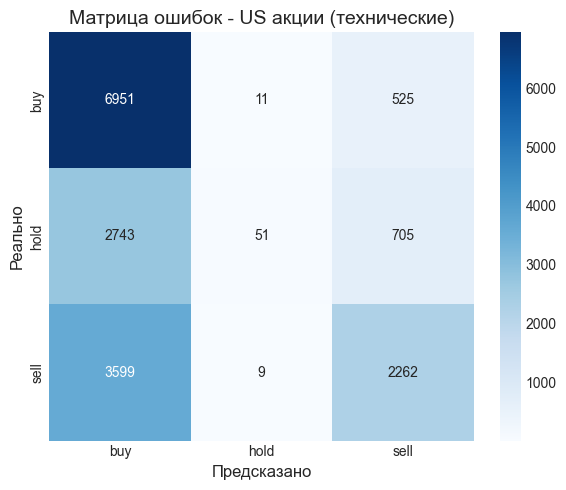


Анализ ошибок для US акции (технические):
   Правильно предсказано: 9264/16856 (55.0%)
   Ошибок всего: 7592 (45.0%)


In [17]:
def plot_confusion_matrix(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['buy', 'hold', 'sell'],
                yticklabels=['buy', 'hold', 'sell'])
    plt.xlabel('Предсказано', fontsize=12)
    plt.ylabel('Реально', fontsize=12)
    plt.title(f'Матрица ошибок - {title}', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Анализ ошибок
    print(f"\nАнализ ошибок для {title}:")
    print(f"   Правильно предсказано: {cm.trace()}/{cm.sum()} ({cm.trace()/cm.sum()*100:.1f}%)")
    
    # Ошибки между классами
    misclassified = cm.sum() - cm.trace()
    print(f"   Ошибок всего: {misclassified} ({misclassified/cm.sum()*100:.1f}%)")

plot_confusion_matrix(model_kz, Xk_test, yk_test, "KZ акции")
plot_confusion_matrix(model_us_tech, Xu_tech_test, yu_tech_test, "US акции (технические)")

In [19]:
best_model = max([("KZ (технические)", acc_kz), 
                  ("US (технические)", acc_us_tech),
                  ("US (фундаментальные)", acc_us_fund)], key=lambda x: x[1])

print(f"""
ЛУЧШАЯ МОДЕЛЬ: {best_model[0]} с accuracy = {best_model[1]:.4f} ({best_model[1]*100:.1f}%)

КЛЮЧЕВЫЕ ВЫВОДЫ:
1. Казахстанский рынок предсказывается ЛУЧШЕ ({acc_kz*100:.1f}% vs {acc_us_tech*100:.1f}%)
    Возможно, рынок менее эффективен  больше аномалий для захвата

2. Технические признаки важнее фундаментальных
    Для краткосрочного прогнозирования (20 дней) технический анализ работает лучше

3. Бейзлайн показал {dummy_acc*100:.1f}%
    Наша модель лучше бейзлайна на {(acc_kz - dummy_acc)*100:.1f}%

""")


ЛУЧШАЯ МОДЕЛЬ: KZ (технические) с accuracy = 0.6769 (67.7%)

КЛЮЧЕВЫЕ ВЫВОДЫ:
1. Казахстанский рынок предсказывается ЛУЧШЕ (67.7% vs 55.0%)
    Возможно, рынок менее эффективен  больше аномалий для захвата

2. Технические признаки важнее фундаментальных
    Для краткосрочного прогнозирования (20 дней) технический анализ работает лучше

3. Бейзлайн показал 38.2%
    Наша модель лучше бейзлайна на 29.5%




In [20]:
joblib.dump(model_kz, 'model_kz.pkl')
joblib.dump(le_kz, 'label_encoder_kz.pkl')
joblib.dump(scaler_kz, 'scaler_kz.pkl')
joblib.dump(tech_features, 'features_list.pkl')

print("Модель сохранена как 'model_kz.pkl'")
print("Label encoder сохранён как 'label_encoder_kz.pkl'")
print("Scaler сохранён как 'scaler_kz.pkl'")
print("Список признаков сохранён как 'features_list.pkl'")

Модель сохранена как 'model_kz.pkl'
Label encoder сохранён как 'label_encoder_kz.pkl'
Scaler сохранён как 'scaler_kz.pkl'
Список признаков сохранён как 'features_list.pkl'
